In [1]:
%load_ext autoreload
%autoreload 2

import gc
import logging
from pathlib import Path

import shap
import xgboost as xgb
from Dataset import Dataset
from newutils.other.helpers import init_context

init_context()

In [7]:
for cluster in range(9):
    import matplotlib.pyplot as plt
    import pandas as pd

    df = pd.read_parquet(
        "/root/2025-Project-188/artifacts/dataset/full_parquet.parquet"
    )
    clusters = pd.read_csv(
        "/root/2025-Project-188/artifacts/dataset/clusters.csv", index_col="gauge_id"
    )
    gauges = clusters[clusters["cluster"] == cluster].index.to_list()
    df = df[df["gauge_id"].isin(gauges)]
    df = df.sample(frac=0.05, random_state=30)
    len(df)

    X_sample_pd = df.drop(
        columns=Dataset.LAGS_COLUMNS + ["q_mm_day"] + Dataset.OTHER_X_DROPS
    )
    y_sample_pd = df[["q_mm_day"]]

    OUTDIR_PLOTS = Path("/root/2025-Project-188/artifacts/plots/shaps/gb")
    OUTDIR_PLOTS.mkdir(parents=True, exist_ok=True)

    booster = xgb.Booster()
    booster.load_model(
        "/root/2025-Project-188/artifacts/gradient_boosting_1000/models/model2025-05-22_130645.json"
    )
    # 2. Build the explainer & compute SHAP values -------------------------------
    explainer = shap.TreeExplainer(booster)
    shap_values = explainer.shap_values(X_sample_pd, y_sample_pd)

    # --- create the plot exactly as before -------------
    plt.figure()
    shap.summary_plot(
        shap_values, X_sample_pd, plot_type="bar", max_display=10, show=False
    )
    plt.tight_layout()

    # --- save the current figure as a PDF --------------
    plt.savefig(
        OUTDIR_PLOTS / f"shap_top10_bar_{cluster}.pdf",
        bbox_inches="tight",
        format="pdf",
    )
    plt.close()

    # --- create the plot exactly as before -------------
    plt.figure()
    shap.summary_plot(shap_values, X_sample_pd, max_display=10, show=False)
    plt.title(f"GB SHAPS (Cluster {cluster})")
    plt.tight_layout()

    # --- save the current figure as a PDF --------------
    plt.savefig(
        OUTDIR_PLOTS / f"shap_top10_{cluster}.pdf", bbox_inches="tight", format="pdf"
    )
    plt.close()

In [5]:
# 1. Compute the raw data arrays
X_test = X_sample_pd
y_test = y_sample_pd

# 2. Create a test DMatrix
dtest = xgb.DMatrix(data=X_test, label=y_test)

In [10]:
y_preds = booster.predict(dtest)

/root/.cache/pypoetry/virtualenvs/pro-1-experiments-3s_W9-_F-py3.11/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [15:06:33] WARNING: /workspace/src/common/error_msg.cc:52: Empty dataset at worker: 0
  warnings.warn(smsg, UserWarning)


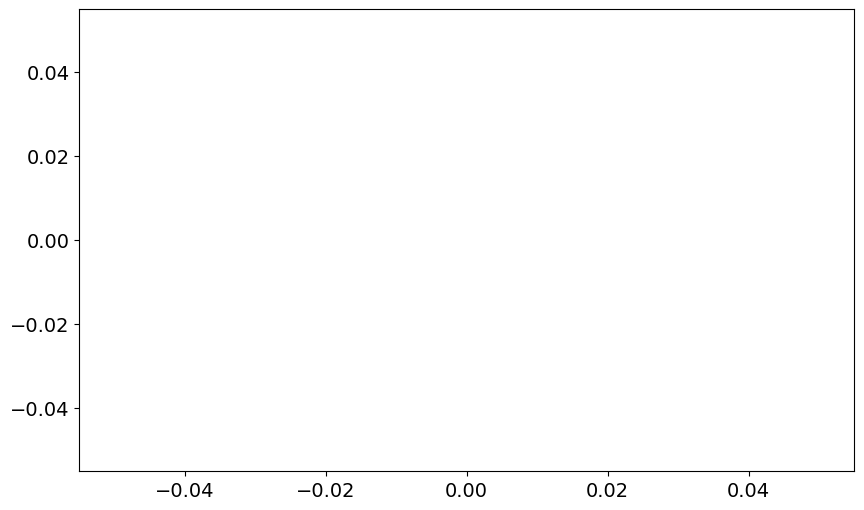

In [6]:
import matplotlib.pyplot as plt

import pandas as pd
dfplot = pd.read_parquet("/root/2025-Project-188/artifacts/dataset/full_parquet.parquet")
clusters = pd.read_csv("/root/2025-Project-188/artifacts/dataset/clusters.csv", index_col="gauge_id")
gauges = clusters[clusters["cluster"] == cluster].index.to_list()[0]
dfplot = dfplot[dfplot["gauge_id"] == gauges]
dfplot =dfplot.sort_values(by="date")

X_sample_pd_plot = dfplot.drop(columns=Dataset.LAGS_COLUMNS + ["q_mm_day"] + Dataset.OTHER_X_DROPS)
y_sample_pd_plot  = dfplot[["q_mm_day"]]

# 1. Compute the raw data arrays
X_test_plot = X_sample_pd_plot
y_test_plot = y_sample_pd_plot

# 2. Create a test DMatrix
dtest_plot = xgb.DMatrix(data=X_test_plot, label=y_test_plot)
y_preds = booster.predict(dtest_plot)

plt.figure(figsize=(10, 6))
plt.plot(y_test_plot[:1000])
plt.plot(y_preds[:1000])

NameError: name 'y_test_plot' is not defined

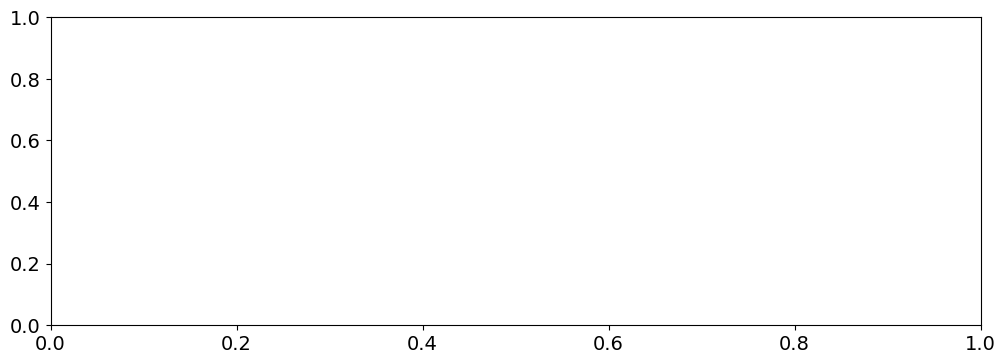

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update(
    {
        "figure.figsize": (12, 4),  # bigger by default
        "font.size": 14,  # readable from the back row
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "legend.fontsize": 12,
        "grid.linestyle": ":",
        "grid.linewidth": 0.75,
    }
)

fig, ax = plt.subplots()

ax.plot([i for i in range(2000, 3000)], y_test_plot[2000:3000], label="True", linewidth=2.5)

ax.plot(
    [i for i in range(2000, 3000)],
    y_preds[2000:3000],
    label="Prediction",
    linewidth=2.5,
    linestyle="--",
    alpha=0.6,
    color="orange",
)

ax.set_title("Gradient Boosting prediction")
# ax.set_xlabel("Sample index")
# ax.set_ylabel("Value")
ax.grid(True)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("Gradient_prediction.pdf", format="pdf", bbox_inches="tight")

plt.close(fig)

In [ ]:
forest_models = [name for name in Path("artifacts/Fast and Small/models/forest_50").iterdir()]
forest_models

[PosixPath('artifacts/Fast and Small/models/forest_50/model2025-05-18_113048.json'),
 PosixPath('artifacts/Fast and Small/models/forest_50/model2025-05-18_113315.json'),
 PosixPath('artifacts/Fast and Small/models/forest_50/model2025-05-18_113530.json')]

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.figsize": (12, 4),        # bigger by default
    "font.size": 14,                  # readable from the back row
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "grid.linestyle": ":",
    "grid.linewidth": 0.75,
})

fig, ax = plt.subplots()

ax.plot(
    [i for i in range(2000, 3000)],
    y_test[2000:3000], 
    label="True", 
    linewidth=2.5
)

for i, model in enumerate(forest_models):
    booster = xgb.Booster()
    booster.load_model(model)
    y_preds = booster.predict(dtest)
    ax.plot(
    [i for i in range(2000, 3000)],
        y_preds[2000:3000], 
        label="Prediction" if i == 0 else None,
        linewidth=2.5, 
        linestyle="--",
        alpha=0.6,
        color="orange"
    )

ax.set_title("Random forest prediction")
# ax.set_xlabel("Sample index")
# ax.set_ylabel("Value")
ax.grid(True)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("forest_prediction.pdf", format="pdf", bbox_inches="tight")

plt.close(fig)


In [ ]:
import numpy as np
import xgboost as xgb
from pathlib import Path

def nse(y_true, y_pred):
    num = np.sum((y_true - y_pred) ** 2)
    den = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - num / den if den != 0 else np.nan

def mape(y_true, y_pred, eps=1e-12):
    mask = np.abs(y_true) > eps        # avoid division by ~0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# ---------- evaluation loop ----------
dtest = xgb.DMatrix(X_test)            # reuse existing test matrix
results = []                           # list of dicts per model

for model_path in Path("artifacts/Fast and Small/models/forest_50").glob("*.json"):
    booster = xgb.Booster()
    booster.load_model(model_path)
    y_pred = booster.predict(dtest)

    results.append({
        "model": model_path.name,
        "NSE" : nse(y_test, y_pred),
        "MAPE": mape(y_test, y_pred),
        "RMSE": rmse(y_test, y_pred),
        "MAE" : mae(y_test, y_pred),
    })

# Pretty print or convert to a DataFrame
from pprint import pprint
results


[{'model': 'model2025-05-18_113048.json',
  'NSE': -398.6169128417969,
  'MAPE': 1355.3627014160156,
  'RMSE': 60.82149,
  'MAE': 36.439434},
 {'model': 'model2025-05-18_113315.json',
  'NSE': -398.6666259765625,
  'MAPE': 1355.4526329040527,
  'RMSE': 60.825275,
  'MAE': 36.480297},
 {'model': 'model2025-05-18_113530.json',
  'NSE': -398.2633972167969,
  'MAPE': 1354.719066619873,
  'RMSE': 60.794582,
  'MAE': 36.458748}]

In [ ]:
import pandas as pd
pd.DataFrame(results).drop(columns=["model"]).mean(axis=0)

NSE     -398.515645
MAPE    1355.178134
RMSE      60.813782
MAE       36.459492
dtype: float64

In [ ]:
import numpy as np
import xgboost as xgb
from pathlib import Path

def nse(y_true, y_pred):
    num = np.sum((y_true - y_pred) ** 2)
    den = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - num / den if den != 0 else np.nan

def mape(y_true, y_pred, eps=1e-12):
    mask = np.abs(y_true) > eps        # avoid division by ~0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# ---------- evaluation loop ----------
dtest = xgb.DMatrix(X_test)            # reuse existing test matrix
results = []                           # list of dicts per model

for model_path in Path("artifacts/Fast and Small/models/boosting").glob("*.json"):
    booster = xgb.Booster()
    booster.load_model(model_path)
    y_pred = booster.predict(dtest)

    results.append({
        "model": model_path.name,
        "NSE" : nse(y_test, y_pred),
        "MAPE": mape(y_test, y_pred),
        "RMSE": rmse(y_test, y_pred),
        "MAE" : mae(y_test, y_pred),
    })

# Pretty print or convert to a DataFrame
from pprint import pprint
results


[{'model': 'model2025-05-18_094431.json',
  'NSE': 0.47283935546875,
  'MAPE': 26.955628395080566,
  'RMSE': 2.2090554,
  'MAE': 0.8505266},
 {'model': 'model2025-05-18_095413.json',
  'NSE': 0.4667809009552002,
  'MAPE': 27.02045440673828,
  'RMSE': 2.221713,
  'MAE': 0.8546919},
 {'model': 'model2025-05-18_095857.json',
  'NSE': 0.4754769802093506,
  'MAPE': 26.92475914955139,
  'RMSE': 2.2035222,
  'MAE': 0.8485526},
 {'model': 'model2025-05-18_093933.json',
  'NSE': 0.4661712646484375,
  'MAPE': 27.104276418685913,
  'RMSE': 2.222983,
  'MAE': 0.85664195},
 {'model': 'model2025-05-18_100352.json',
  'NSE': 0.463994562625885,
  'MAPE': 27.103528380393982,
  'RMSE': 2.2275105,
  'MAE': 0.85724676},
 {'model': 'model2025-05-18_094939.json',
  'NSE': 0.4731908440589905,
  'MAPE': 26.943546533584595,
  'RMSE': 2.208319,
  'MAE': 0.850142}]

In [ ]:
import pandas as pd
pd.DataFrame(results).drop(columns=["model"]).mean(axis=0)

NSE      0.469742
MAPE    27.008699
RMSE     2.215517
MAE      0.852967
dtype: float64